#Advanced SQL

Q1. What is a Common Table Expression (CTE), and how does it improve SQL query readability?

- A Common Table Expression (CTE) is a temporary, named result set that exists only during the execution of a SQL statement. It is defined using the WITH clause and can be referenced within a SELECT, INSERT, UPDATE, or DELETE query.

$$
SQL Syntax
$$

In [ ]:
WITH cte_name AS (
    SELECT column1, column2
    FROM table_name
    WHERE condition
)
SELECT *
FROM cte_name;

- how does it improve SQL query readability

    **Break complex queries into logical steps :-**

   Large queries become easier to understand by separating calculations and filtering into named sections.

  **Reduce repetition**

   If the same subquery is needed multiple times, define it once in a CTE and reuse it.

   **Improve maintainability**

   Changes can be made in one place instead of updating multiple nested subqueries.

   **Make recursive queries easier**

   CTEs support recursion, making hierarchical data (e.g., employee-manager relationships) easier to query.


Q2. Why are some views updatable while others are read-only? Explain with an example.

- A view is a virtual table created from the result of a SQL query. Whether a view is updatable or read-only depends on how it is defined.

-   **Updatable Views**

    A view is generally updatable when:-

    It is based on one table.

    I t does not contain aggregate functions (SUM, AVG, COUNT, etc.).

    It does not use GROUP BY, DISTINCT, or UNION.

    Each row in the view corresponds directly to a single row in the base table.

   Example:-

In [ ]:
CREATE VIEW EmployeeView AS
SELECT employee_id, employee_name, salary
FROM Employees;

-- You can update data through this view:-

UPDATE EmployeeView
SET salary = 60000
WHERE employee_id = 101;

-   **Read-Only Views**

    A view becomes read-only when it contains:-

    Aggregate functions (SUM, AVG, COUNT, etc.).

    GROUP BY, DISTINCT, or UNION.

    Joins that make updates ambiguous.

    Calculated or derived columns.

Example:-

In [ ]:
CREATE VIEW DepartmentSalarySummary AS
SELECT department_id, AVG(salary) AS avg_salary
FROM Employees
GROUP BY department_id;

-- Try to update this view:-

UPDATE DepartmentSalarySummary
SET avg_salary = 70000
WHERE department_id = 10;

-- Give an error because avg_salary is a calculated value, and SQL cannot determine which employee records should be updated.

Q3. What advantages do stored procedures offer compared to writing raw SQL queries repeatedly?

- A Stored Procedure is a precompiled collection of SQL statements stored in the database that can be executed whenever needed.

- **Advantages of Stored Procedures:-**

   Reduces Code Repetition

   Improves Performance

   Enhances Security

   Easier Maintenance

   Supports Complex Business Logic

   Reduces Network Traffic


Q4. What is the purpose of triggers in a database? Mention one use case where a trigger is essential.

- Purpose of Triggers in a Database:-
  
  A trigger is a special type of stored program that automatically executes (fires) when a specific event occurs in a database table, such as INSERT, UPDATE, or DELETE operations.

- Use case where a trigger is essential :-

  **Audit Logging**

  A trigger can automatically record changes made to important data. For example, whenever an employee's salary is updated, a trigger can store the old salary, new salary, date, and user information in an audit table.

$$
Example Query
$$

In [ ]:
CREATE TRIGGER SalaryAudit
AFTER UPDATE ON Employees
FOR EACH ROW
INSERT INTO Salary_Log
(Employee_ID, Old_Salary, New_Salary, Change_Date)
VALUES
(OLD.Employee_ID, OLD.Salary, NEW.Salary, NOW());

Q5. Explain the need for data modelling and normalization when designing a database.

- Data Modelling is the process of creating a structure for storing data in a database. It helps define tables, relationships, attributes, and constraints before implementation.

  **Need for Data Modelling:-**

  Provides a clear blueprint of the database.

  Identifies relationships between entities.

  Improves data organization and consistency.

  Reduces design errors and development time.

  Makes the database easier to maintain and scale.

- Normalization is the process of organizing data into related tables to minimize redundancy and improve data integrity.

  **Need for Normalization:-**

  Eliminates duplicate data.

  Prevents insertion, update, and deletion anomalies.

  Improves data consistency and accuracy.

  Makes storage more efficient.

  Simplifies database maintenance.

Q6. Write a CTE to calculate the total revenue for each product
 (Revenues = Price × Quantity), and return only products where  revenue > 3000.

 $$
 SQL Query
 $$

In [ ]:
SELECT
    p.ProductID,
    p.ProductName,
    p.Price,
    s.Quantity,
    (p.Price * s.Quantity) AS Revenue
FROM Products p
JOIN Sales s
    ON p.ProductID = s.ProductID
WHERE (p.Price * s.Quantity) > 3000;


$$
OUTPUT
$$

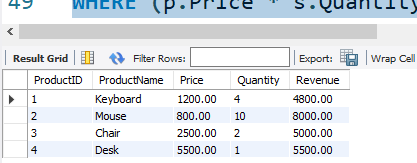

Q7. Create a view named vw_CategorySummary that shows:
 Category, TotalProducts, AveragePrice.

 $$
 SQL Query
 $$

In [ ]:
CREATE VIEW vw_CatagorySummary AS
SELECT
    Catagory,
    COUNT(*) AS TotalProducts,
    AVG(Price) AS AveragePrice
FROM Products
GROUP BY Catagory;


$$
OUTPUT
$$

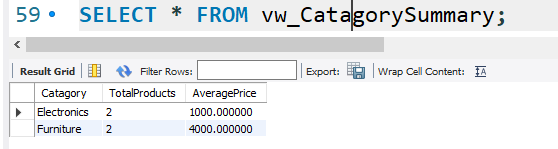

Q8. Create an updatable view containing ProductID, ProductName, and Price.
 Then update the price of ProductID = 1 using the view.

 $$
 SQL Query
 $$

In [ ]:
CREATE VIEW vw_ProductDetails AS
SELECT
    productID,
    productName,
    Price
FROM Products;

-- Update the price using the view
--change the price of ProductID = 1 to 1500:-

UPDATE vw_ProductDetails
SET Price = 1500
WHERE productID = 1;


$$
OUTPUT
$$

$$
Before
$$
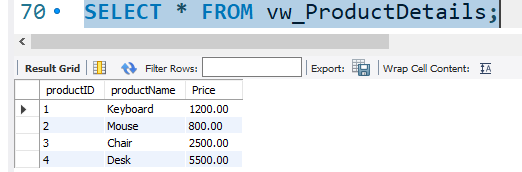

$$
After
$$

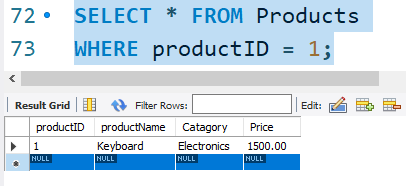

Q9. Create a stored procedure that accepts a category name and returns all products belonging to that
category.

$$
SQL Query
$$


In [ ]:
DELIMITER //

CREATE PROCEDURE GetProductsByCategory(
    IN p_Catagory VARCHAR(50)
)
BEGIN
    SELECT
        productID,
        productName,
        Catagory,
        Price
    FROM Products
    WHERE Catagory = p_Catagory;
END //

DELIMITER ;

-- To call furniture:-

CALL GetProductsByCategory('Furniture');


$$
OUTPUT
$$

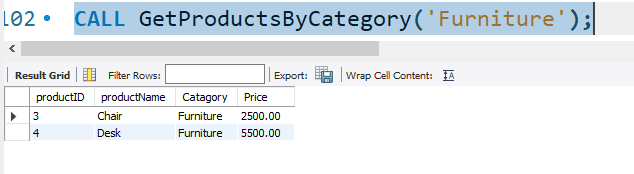

In [ ]:
-- To call Electronics :-

CALL GetProductsByCategory('Electronics');


$$
OUTPUT
$$

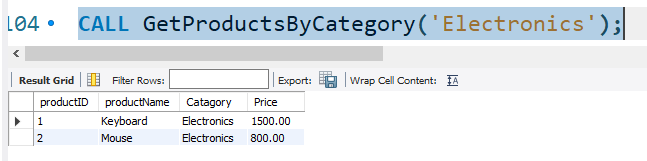

Q10. Create an AFTER DELETE trigger on the Products table that archives deleted product rows into a new
table ProductArchive. The archive should store ProductID, ProductName, Category, Price, and DeletedAt
timestamp.

$$
SQL Query
$$

In [ ]:
-- Create Archive Table:-

CREATE TABLE ProductArchive (
    ProductID INT,
    ProductName VARCHAR(100),
    Catagory VARCHAR(50),
    Price DECIMAL(10,2),
    DeletedAt TIMESTAMP
);

-- AFTER DELETE Trigger:-

DELIMITER //

CREATE TRIGGER trg_AfterDeleteProduct
AFTER DELETE ON Products
FOR EACH ROW
BEGIN
    INSERT INTO ProductArchive
    (ProductID, ProductName, Catagory, Price, DeletedAt)
    VALUES
    (OLD.productID, OLD.productName, OLD.Catagory, OLD.Price, NOW());
END //

DELIMITER ;

-- Delete a product:-

DELETE FROM Products
WHERE productID = 5;

-- The Archived Record result:-

SELECT * FROM ProductArchive;

$$
OUTPUT
$$

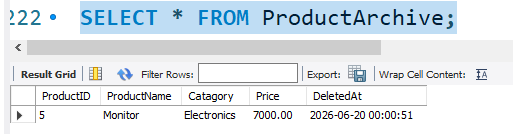

$$
***
$$